# Notebook 95 - three-point fascicle speckle displacement and strain

This exploratory notebook uses the validated `june30_4_best` run to build a simplified, Frich et al. 2019-inspired speckle tracking analysis:

1. Load the same grayscale video frames used by the strict UltraTimTrack run.
2. Reuse the saved best fascicle segment on the reference frame.
3. Select three textured speckle points along the central fascicle line.
4. Track local patches with the existing ZNCC/NCC patch-matching logic from `ultrasound_tracker.speckle_confidence`.
5. Report x/y displacement, displacement parallel/perpendicular to the fascicle, and longitudinal strain between back-center-front points.

The sign convention is:

- Negative strain = shortening along the reference fascicle direction.
- Positive strain = lengthening along the reference fascicle direction.

This notebook is intentionally an experiment. It does not modify the main UltraTimTrack package.


In [1]:
from __future__ import annotations

import copy
import json
import math
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/matplotlib")

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "ultrasound_tracker").exists():
    ROOT = ROOT.parent.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.speckle_confidence import (  # noqa: E402
    SpeckleConfidenceConfig,
    compute_speckle_coherence,
    zncc,
    _gray_float,
    _match_patch_at,
)
from ultrasound_tracker.ultratrack_klt import read_gray_frames  # noqa: E402
from ultrasound_tracker.geometry import line_length_from_array  # noqa: E402

DATASET_NAME = "june30_4_best"
OUT_DIR = ROOT / "results" / DATASET_NAME
FIG_DIR = OUT_DIR / "three_point_speckle_figures"
CSV_PATH = OUT_DIR / "three_point_fascicle_speckle_tracking.csv"
VIDEO_OVERLAY_PATH = FIG_DIR / "three_point_speckle_overlay.mp4"

OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

CFG = SpeckleConfidenceConfig(
    block_size=21,
    stride=24,
    search_radius=8,
    min_texture_variance=5.0,
    zncc_low=0.45,
    zncc_high=0.90,
    forward_backward_scale_px=2.0,
)
ZNCC_THRESHOLD = float(CFG.zncc_low)
FB_ERROR_THRESHOLD_PX = float(CFG.forward_backward_scale_px)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 180,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"Project root: {ROOT}")
print(f"Output CSV: {CSV_PATH}")
print(f"Figure directory: {FIG_DIR}")


Matplotlib is building the font cache; this may take a moment.


Project root: /Users/grosbedou/PycharmProjects/NDORMS
Output CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_fascicle_speckle_tracking.csv
Figure directory: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_figures


## Locate the validated run

The notebook prefers the saved strict run artifacts for `june30_4_best`.
If those are unavailable, it has a detector fallback, but the saved run is the scientifically cleaner path here because it uses the already validated line selection.


In [2]:
def resolve_existing_path(value, fallback: Path | None = None) -> Path:
    candidates: list[Path] = []
    if value:
        p = Path(str(value)).expanduser()
        candidates.append(p if p.is_absolute() else ROOT / p)
        candidates.append(ROOT / p.name)
    if fallback is not None:
        candidates.append(fallback)
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    if candidates:
        return candidates[0].resolve()
    raise FileNotFoundError("No path candidate was supplied.")


def find_validated_run_dir(name: str) -> Path:
    dirs: list[Path] = []
    primary = ROOT / "results" / "strict_ultratimtrack_runs" / name
    if primary.exists():
        dirs.append(primary)
    for npz in sorted((ROOT / "results").glob(f"**/{name}_strict_results.npz")):
        dirs.append(npz.parent)

    seen: set[Path] = set()
    for directory in dirs:
        directory = directory.resolve()
        if directory in seen:
            continue
        seen.add(directory)
        if (directory / f"{name}_strict_results.npz").exists():
            return directory
    raise FileNotFoundError(f"Could not find saved strict results for {name!r}.")


def finite_scalar(value, default=np.nan) -> float:
    try:
        arr = np.asarray(value, dtype=np.float64).reshape(-1)
        if arr.size and np.isfinite(arr[0]):
            return float(arr[0])
    except Exception:
        pass
    return float(default)


def video_fps_and_count(path: Path) -> tuple[float, int]:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        raise FileNotFoundError(path)
    fps = float(cap.get(cv2.CAP_PROP_FPS))
    n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return fps, n_frames


STRICT_RUN_DIR = find_validated_run_dir(DATASET_NAME)
NPZ_PATH = STRICT_RUN_DIR / f"{DATASET_NAME}_strict_results.npz"
METADATA_PATH = STRICT_RUN_DIR / f"{DATASET_NAME}_strict_metadata.json"

metadata = json.loads(METADATA_PATH.read_text()) if METADATA_PATH.exists() else {}
npz = np.load(NPZ_PATH, allow_pickle=True)
arrays = {key: npz[key] for key in npz.files}
npz.close()

VIDEO_PATH = resolve_existing_path(metadata.get("video"), ROOT / "data" / "raw" / f"{DATASET_NAME}.AVI")
ROI_PATH = resolve_existing_path(metadata.get("roi_path"), ROOT / "data" / "rois" / f"{DATASET_NAME}_rois.json")
rois = json.loads(ROI_PATH.read_text()) if ROI_PATH.exists() else {}

fps_cv2, n_video_frames = video_fps_and_count(VIDEO_PATH)
fps = finite_scalar(metadata.get("fps", np.nan), default=fps_cv2)
if not np.isfinite(fps) or fps <= 0:
    fps = fps_cv2 if fps_cv2 > 0 else np.nan

n_from_results = int(np.asarray(arrays.get("frame", [])).reshape(-1).size)
n_to_load = n_from_results if n_from_results > 0 else n_video_frames
frames = read_gray_frames(VIDEO_PATH, limit=n_to_load)
if not frames:
    raise RuntimeError(f"No frames were read from {VIDEO_PATH}")

frame_shape = frames[0].shape[:2]
if len(frames) < n_to_load:
    warnings.warn(f"Requested {n_to_load} frames but read {len(frames)} frames.")

mm_per_pixel = finite_scalar(arrays.get("mm_per_pixel", metadata.get("mm_per_pixel", np.nan)))
has_mm_calibration = bool(np.isfinite(mm_per_pixel) and mm_per_pixel > 0)

print(f"Strict run directory: {STRICT_RUN_DIR}")
print(f"Video: {VIDEO_PATH}")
print(f"ROI file: {ROI_PATH}")
print(f"Frames loaded: {len(frames)} of video count {n_video_frames}; fps={fps}")
print(f"Frame shape: {frame_shape}")
print(f"mm_per_pixel: {mm_per_pixel if has_mm_calibration else 'not found'}")
print(f"ROIs: {rois}")


Strict run directory: /Users/grosbedou/PycharmProjects/NDORMS/results/strict_ultratimtrack_runs/june30_4_best
Video: /Users/grosbedou/PycharmProjects/NDORMS/data/raw/june30_4_best.AVI
ROI file: /Users/grosbedou/PycharmProjects/NDORMS/data/rois/june30_4_best_rois.json
Frames loaded: 84 of video count 84; fps=11.0
Frame shape: (800, 800)
mm_per_pixel: 0.063375
ROIs: {'superficial': [179, 63, 444, 62], 'deep': [177, 321, 446, 64], 'fascicle': [180, 107, 442, 228]}


## Reference fascicle line

The strict runner stores MATLAB-style one-based line coordinates. For image indexing, patch extraction, and overlays below, saved line coordinates are converted to zero-based coordinates by subtracting one pixel from x and y.


In [3]:
ONE_BASED_OFFSET = np.array([1.0, 1.0, 1.0, 1.0], dtype=np.float64)


def finite_segment(segment) -> bool:
    arr = np.asarray(segment, dtype=np.float64).reshape(-1)
    return arr.size >= 4 and np.all(np.isfinite(arr[:4])) and line_length_from_array(arr[:4]) > 1.0


def detector_fallback_reference_segment(frame0: np.ndarray) -> tuple[np.ndarray, str]:
    from scipy.io import loadmat
    from scripts.run_strict_ultratimtrack_video import (
        apply_aponeurosis_maxangle_overrides,
        apply_fascicle_angle_overrides,
        update_parms_from_rois,
    )
    from ultrasound_tracker.matlab_timtrack import (
        detect_timtrack_geofeature_from_image,
        fascicle_segment_from_geofeature,
    )

    utt_export = resolve_existing_path(metadata.get("utt_export"), ROOT / "data" / "matlab" / "UTT_numeric_export.mat")
    mat_root = loadmat(utt_export, simplify_cells=True)["UTT_numeric_export"]
    parms = copy.deepcopy(mat_root["parms"])
    if rois:
        parms = update_parms_from_rois(parms, rois, frame0.shape[:2])
    parms = apply_aponeurosis_maxangle_overrides(
        parms,
        super_apo_maxangle=metadata.get("apo_fit_maxangle_super_deg"),
        deep_apo_maxangle=metadata.get("apo_fit_maxangle_deep_deg"),
    )
    if metadata.get("fas_angle_min_deg") is not None and metadata.get("fas_angle_max_deg") is not None:
        parms = apply_fascicle_angle_overrides(
            parms,
            fas_angle_min=float(metadata["fas_angle_min_deg"]),
            fas_angle_max=float(metadata["fas_angle_max_deg"]),
        )
    entry = detect_timtrack_geofeature_from_image(
        frame0,
        parms,
        emask_mode="matlab",
        hough_localmax_fallback=bool(metadata.get("hough_localmax_fallback", False)),
        hough_fallback_min_mass_below_10deg=float(metadata.get("hough_fallback_min_mass_below_10deg", 0.25)),
        hough_fallback_min_gap_to_lower_deg=float(metadata.get("hough_fallback_min_gap_to_lower_deg", 4.0)),
    )
    seg_1b = fascicle_segment_from_geofeature(entry, alpha_override=entry.get("alpha"))
    if not finite_segment(seg_1b):
        raise RuntimeError("Detector fallback did not return a finite fascicle segment.")
    return np.asarray(seg_1b, dtype=np.float64) - ONE_BASED_OFFSET, "detector_fallback"


def reference_fascicle_segment_zero_based(frame_idx: int = 0) -> tuple[np.ndarray, str]:
    preferred_keys = [
        "fascicle_end_segments",
        "fascicle_segments",
        "forward_fascicle_end_segments",
        "forward_fascicle_segments",
        "selected_seed_segment",
    ]
    for key in preferred_keys:
        if key not in arrays:
            continue
        arr = np.asarray(arrays[key], dtype=np.float64)
        if arr.ndim == 2 and arr.shape[1] >= 4 and frame_idx < arr.shape[0]:
            seg = arr[frame_idx, :4]
        elif arr.ndim == 1 and arr.size >= 4:
            seg = arr[:4]
        else:
            continue
        if finite_segment(seg):
            return np.asarray(seg, dtype=np.float64) - ONE_BASED_OFFSET, key

    meta_seg = metadata.get("selected_seed_segment")
    if meta_seg is not None and finite_segment(meta_seg):
        return np.asarray(meta_seg, dtype=np.float64) - ONE_BASED_OFFSET, "metadata.selected_seed_segment"

    return detector_fallback_reference_segment(frames[0])


def line_from_array_zero_based(key: str, frame_idx: int = 0) -> np.ndarray | None:
    if key not in arrays:
        return None
    arr = np.asarray(arrays[key], dtype=np.float64)
    if arr.ndim != 2 or frame_idx >= arr.shape[0] or arr.shape[1] < 4:
        return None
    seg = arr[frame_idx, :4]
    if not finite_segment(seg):
        return None
    return seg - ONE_BASED_OFFSET


fascicle_line0, fascicle_source = reference_fascicle_segment_zero_based(0)
p0 = fascicle_line0[:2].astype(np.float64)
p1 = fascicle_line0[2:4].astype(np.float64)
fascicle_length_px = float(np.linalg.norm(p1 - p0))
if fascicle_length_px <= 0:
    raise RuntimeError("Reference fascicle line is degenerate.")

t_hat = (p1 - p0) / fascicle_length_px
n_hat = np.array([-t_hat[1], t_hat[0]], dtype=np.float64)

sup_apo0 = line_from_array_zero_based("sup_apo_lines", 0)
deep_apo0 = line_from_array_zero_based("deep_apo_lines", 0)
fascicle_roi = tuple(int(v) for v in rois.get("fascicle", (0, 0, frame_shape[1], frame_shape[0])))

print(f"Reference fascicle source: {fascicle_source}")
print(f"p0={p0}, p1={p1}")
print(f"fascicle_length_px={fascicle_length_px:.2f}")
print(f"t_hat={t_hat}, n_hat={n_hat}")


Reference fascicle source: fascicle_end_segments
p0=[954.15247618  88.16589879], p1=[-156.15248108  344.5       ]
fascicle_length_px=1139.51
t_hat=[-0.97437006  0.22495106], n_hat=[-0.22495106 -0.97437006]


## Patch-matching helpers

These helpers deliberately wrap the same `_match_patch_at` routine that powers `compute_speckle_coherence`, and re-score the matched template with the public `zncc` function. This keeps the experiment aligned with the existing NCC/ZNCC implementation while allowing point-level tracking records.


In [4]:
POINT_ORDER = ["back", "center", "front"]
POINT_COLORS = {
    "back": "tab:orange",
    "center": "tab:cyan",
    "front": "tab:green",
}


def extract_patch(frame: np.ndarray, point: np.ndarray, block_size: int) -> np.ndarray | None:
    gray = _gray_float(frame)
    half = int(block_size) // 2
    x, y = np.rint(np.asarray(point, dtype=np.float64)).astype(int)
    if x - half < 0 or x + half + 1 > gray.shape[1]:
        return None
    if y - half < 0 or y + half + 1 > gray.shape[0]:
        return None
    return gray[y - half : y + half + 1, x - half : x + half + 1]


def point_in_roi(point: np.ndarray, roi: tuple[int, int, int, int] | None, margin: float = 0.0) -> bool:
    if roi is None:
        return True
    x, y = [float(v) for v in np.asarray(point).reshape(2)]
    rx, ry, rw, rh = [float(v) for v in roi]
    return (rx + margin) <= x <= (rx + rw - margin) and (ry + margin) <= y <= (ry + rh - margin)


def valid_patch_center(
    point: np.ndarray,
    shape: tuple[int, int],
    cfg: SpeckleConfidenceConfig,
    roi: tuple[int, int, int, int] | None = None,
    aponeurosis_lines: list[np.ndarray | None] | None = None,
    aponeurosis_margin_px: float | None = None,
) -> bool:
    if point is None:
        return False
    point = np.asarray(point, dtype=np.float64).reshape(2)
    if not np.all(np.isfinite(point)):
        return False
    half = int(cfg.block_size) // 2
    radius = int(cfg.search_radius)
    margin = half + radius
    height, width = int(shape[0]), int(shape[1])
    x, y = point
    if not (margin <= x <= width - 1 - margin and margin <= y <= height - 1 - margin):
        return False
    if roi is not None and not point_in_roi(point, roi, margin=half):
        return False
    if aponeurosis_lines:
        apo_margin = float(aponeurosis_margin_px if aponeurosis_margin_px is not None else half + 2)
        for line in aponeurosis_lines:
            if line is None:
                continue
            if point_to_line_distance(point, line) < apo_margin:
                return False
    return True


def point_to_line_distance(point: np.ndarray, line: np.ndarray) -> float:
    point = np.asarray(point, dtype=np.float64).reshape(2)
    line = np.asarray(line, dtype=np.float64).reshape(4)
    a = line[:2]
    b = line[2:]
    denom = float(np.linalg.norm(b - a))
    if denom <= 1e-12:
        return float("nan")
    return float(abs(np.cross(b - a, point - a)) / denom)


def match_point_once(prev_frame: np.ndarray, curr_frame: np.ndarray, point: np.ndarray, cfg: SpeckleConfidenceConfig) -> dict:
    prev = _gray_float(prev_frame)
    curr = _gray_float(curr_frame)
    forward = _match_patch_at(prev, curr, point, cfg)
    if forward is None:
        return {"ok": False, "point": np.full(2, np.nan), "zncc": np.nan, "cv_score": np.nan}

    matched_point, cv_score = forward
    template = extract_patch(prev, point, int(cfg.block_size))
    matched_patch = extract_patch(curr, matched_point, int(cfg.block_size))
    z = float("nan")
    if template is not None and matched_patch is not None:
        z = zncc(template, matched_patch, min_texture_variance=float(cfg.min_texture_variance))
    if not np.isfinite(z):
        z = float(cv_score)
    return {"ok": True, "point": np.asarray(matched_point, dtype=np.float64), "zncc": float(z), "cv_score": float(cv_score)}


def match_point_with_fb(prev_frame: np.ndarray, curr_frame: np.ndarray, point: np.ndarray, cfg: SpeckleConfidenceConfig) -> dict:
    forward = match_point_once(prev_frame, curr_frame, point, cfg)
    if not forward["ok"]:
        return {**forward, "forward_backward_error": np.nan}

    reverse = match_point_once(curr_frame, prev_frame, forward["point"], cfg)
    if reverse["ok"]:
        fb_error = float(np.linalg.norm(reverse["point"] - np.asarray(point, dtype=np.float64).reshape(2)))
    else:
        fb_error = float("nan")
    return {**forward, "forward_backward_error": fb_error}


## Synthetic sanity checks

Before touching the real sequence, test that the point-level wrapper recovers a known patch shift and that the fascicle projection formula is exactly the expected dot product.


In [5]:
rng = np.random.default_rng(95)
synthetic = rng.normal(loc=128.0, scale=35.0, size=(80, 80)).astype(np.float32)
synthetic = cv2.GaussianBlur(synthetic, (0, 0), sigmaX=1.1)
synthetic = np.clip(synthetic, 0, 255).astype(np.uint8)

known_shift = np.array([4.0, -3.0], dtype=np.float64)
matrix = np.float32([[1, 0, known_shift[0]], [0, 1, known_shift[1]]])
shifted = cv2.warpAffine(
    synthetic,
    matrix,
    (synthetic.shape[1], synthetic.shape[0]),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_REFLECT,
)

synthetic_center = np.array([40.0, 40.0], dtype=np.float64)
synthetic_match = match_point_with_fb(synthetic, shifted, synthetic_center, CFG)
recovered_shift = synthetic_match["point"] - synthetic_center
print(f"Known shift: {known_shift}, recovered shift: {recovered_shift}, ZNCC={synthetic_match['zncc']:.3f}, FB={synthetic_match['forward_backward_error']:.3f}")
assert np.allclose(recovered_shift, known_shift, atol=0.75), "Synthetic patch shift was not recovered."

test_disp = np.array([5.0, -2.0], dtype=np.float64)
d_parallel = float(np.dot(test_disp, t_hat))
expected = float(test_disp[0] * t_hat[0] + test_disp[1] * t_hat[1])
print(f"Projection check: {d_parallel:.6f} vs {expected:.6f}")
assert np.isclose(d_parallel, expected), "Projection formula is inconsistent."

# Small sequence-level smoke check using the existing public coherence helper.
coherence_smoke = compute_speckle_coherence(frames[0], frames[1], roi=fascicle_roi, config=CFG)
print(
    "Frame 0->1 coherence smoke:",
    {
        "speckle_zncc": round(float(coherence_smoke["speckle_zncc"]), 4),
        "n_valid_patches": int(coherence_smoke["n_valid_patches"]),
        "n_total_patches": int(coherence_smoke["n_total_patches"]),
    },
)


Known shift: [ 4. -3.], recovered shift: [ 4. -3.], ZNCC=1.000, FB=0.000
Projection check: -5.321752 vs -5.321752
Frame 0->1 coherence smoke: {'speckle_zncc': 0.9622, 'n_valid_patches': 136, 'n_total_patches': 136}


## Select three fascicle texture points

Candidate points are sampled along the central 70 percent of the saved fascicle line. The central point is chosen from a combined patch-variance and frame-0-to-frame-1 ZNCC score. The back/front points are placed by the requested offset, reduced automatically if the resulting patch would be invalid.


In [6]:
def candidate_score_table(
    frame0: np.ndarray,
    frame1: np.ndarray,
    line: np.ndarray,
    cfg: SpeckleConfidenceConfig,
    roi: tuple[int, int, int, int] | None,
    n_samples: int = 141,
) -> pd.DataFrame:
    line = np.asarray(line, dtype=np.float64).reshape(4)
    p_start = line[:2]
    p_end = line[2:]
    fractions = np.linspace(0.15, 0.85, int(n_samples))
    rows = []
    apo_lines = [sup_apo0, deep_apo0]
    for fraction in fractions:
        point = p_start + fraction * (p_end - p_start)
        if not valid_patch_center(point, frame0.shape[:2], cfg, roi=roi, aponeurosis_lines=apo_lines):
            continue
        patch = extract_patch(frame0, point, int(cfg.block_size))
        if patch is None:
            continue
        texture_variance = float(np.var(patch))
        match = match_point_once(frame0, frame1, point, cfg)
        rows.append(
            {
                "fraction": float(fraction),
                "x": float(point[0]),
                "y": float(point[1]),
                "texture_variance": texture_variance,
                "zncc_0_1": float(match["zncc"]),
                "match_ok": bool(match["ok"]),
            }
        )

    table = pd.DataFrame(rows)
    if table.empty:
        raise RuntimeError("No valid candidate points were found along the reference fascicle.")

    q10, q90 = table["texture_variance"].quantile([0.10, 0.90])
    texture_den = max(float(q90 - q10), 1e-12)
    table["texture_score"] = ((table["texture_variance"] - float(q10)) / texture_den).clip(0, 1)
    table["zncc_score"] = ((table["zncc_0_1"] - float(cfg.zncc_low)) / max(float(cfg.zncc_high - cfg.zncc_low), 1e-12)).clip(0, 1)
    table.loc[~np.isfinite(table["zncc_score"]), "zncc_score"] = 0.0
    table["combined_score"] = 0.45 * table["texture_score"] + 0.55 * table["zncc_score"]
    return table.sort_values("combined_score", ascending=False).reset_index(drop=True)


def select_three_points_from_candidates(
    table: pd.DataFrame,
    line: np.ndarray,
    t_axis: np.ndarray,
    length_px: float,
    cfg: SpeckleConfidenceConfig,
    shape: tuple[int, int],
    roi: tuple[int, int, int, int] | None,
) -> tuple[dict[str, np.ndarray], float]:
    center = table.iloc[0][["x", "y"]].to_numpy(dtype=np.float64)
    offset = min(25.0, 0.15 * float(length_px))
    min_offset = max(4.0, float(cfg.block_size // 2))
    apo_lines = [sup_apo0, deep_apo0]
    while offset >= min_offset:
        points = {
            "back": center - offset * t_axis,
            "center": center.copy(),
            "front": center + offset * t_axis,
        }
        if all(valid_patch_center(pt, shape, cfg, roi=roi, aponeurosis_lines=apo_lines) for pt in points.values()):
            return points, float(offset)
        offset *= 0.85
    raise RuntimeError("Could not place three valid points around the selected center point.")


candidate_scores = candidate_score_table(frames[0], frames[1], fascicle_line0, CFG, fascicle_roi)
initial_points, point_offset_px = select_three_points_from_candidates(
    candidate_scores,
    fascicle_line0,
    t_hat,
    fascicle_length_px,
    CFG,
    frame_shape,
    fascicle_roi,
)

candidate_scores.to_csv(OUT_DIR / "three_point_candidate_scores.csv", index=False)

print(f"Selected point offset: {point_offset_px:.2f} px")
for point_id in POINT_ORDER:
    print(f"{point_id:>6}: {initial_points[point_id]}")
display(candidate_scores.head(10))


Selected point offset: 25.00 px
  back: [367.84400129 223.52587801]
center: [343.48474969 229.14965446]
 front: [319.12549809 234.7734309 ]


/var/folders/xv/1j8r4j6525v2s3svp0bnsy1w0000gn/T/ipykernel_58841/2034577404.py:68: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(abs(np.cross(b - a, point - a)) / denom)
/var/folders/xv/1j8r4j6525v2s3svp0bnsy1w0000gn/T/ipykernel_58841/2034577404.py:68: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  return float(abs(np.cross(b - a, point - a)) / denom)


,fraction,x,y,texture_variance,zncc_0_1,match_ok,texture_score,zncc_score,combined_score
0,0.550,343.484750,229.149654,1662.393188,0.987023,True,1.000000,1.0,1.000000
1,0.585,304.624076,238.121348,1013.531372,0.967840,True,1.000000,1.0,1.000000
2,0.590,299.072551,239.403019,1047.291016,0.970229,True,1.000000,1.0,1.000000
3,0.535,360.139324,225.304643,1316.400269,0.987495,True,1.000000,1.0,1.000000
4,0.540,354.587799,226.586313,1691.402466,0.989809,True,1.000000,1.0,1.000000
5,0.545,349.036274,227.867984,1720.996216,0.987848,True,1.000000,1.0,1.000000
6,0.600,287.969502,241.966360,1027.875122,0.982437,True,1.000000,1.0,1.000000
7,0.555,337.933225,230.431325,1387.527222,0.984996,True,1.000000,1.0,1.000000
8,0.595,293.521027,240.684689,989.400818,0.980255,True,0.986743,1.0,0.994034
9,0.580,310.175601,236.839677,891.032043,0.964345,True,0.878659,1.0,0.945396


## Track the three points

For each frame pair `i -> i+1`, each point is matched by local ZNCC. Low-confidence matches are not silently accepted. If a point fails the ZNCC or forward-backward check, its next position is filled using the median displacement from the other valid points in that same frame pair, or the previous valid median displacement if all points fail. Those rows are marked with `valid=False` and `fallback_used=True`.


In [7]:
def track_three_points(
    frames_in: list[np.ndarray],
    points0: dict[str, np.ndarray],
    cfg: SpeckleConfidenceConfig,
    *,
    max_frames: int | None = None,
    zncc_threshold: float = ZNCC_THRESHOLD,
    fb_error_threshold_px: float = FB_ERROR_THRESHOLD_PX,
) -> dict[str, np.ndarray]:
    n_frames = len(frames_in) if max_frames is None else min(int(max_frames), len(frames_in))
    n_points = len(POINT_ORDER)
    positions = np.full((n_frames, n_points, 2), np.nan, dtype=np.float64)
    frame_displacement = np.zeros((n_frames, n_points, 2), dtype=np.float64)
    zncc_scores = np.full((n_frames, n_points), np.nan, dtype=np.float64)
    fb_errors = np.full((n_frames, n_points), np.nan, dtype=np.float64)
    valid = np.zeros((n_frames, n_points), dtype=bool)
    fallback_used = np.zeros((n_frames, n_points), dtype=bool)

    for point_idx, point_id in enumerate(POINT_ORDER):
        positions[0, point_idx] = np.asarray(points0[point_id], dtype=np.float64)
        valid[0, point_idx] = True

    last_median_disp = np.zeros(2, dtype=np.float64)
    for frame_idx in range(n_frames - 1):
        attempted_positions = np.full((n_points, 2), np.nan, dtype=np.float64)
        attempted_displacements = np.full((n_points, 2), np.nan, dtype=np.float64)
        pair_good = np.zeros(n_points, dtype=bool)

        for point_idx in range(n_points):
            prev_point = positions[frame_idx, point_idx]
            if not valid_patch_center(prev_point, frames_in[frame_idx].shape[:2], cfg):
                continue
            match = match_point_with_fb(frames_in[frame_idx], frames_in[frame_idx + 1], prev_point, cfg)
            zncc_scores[frame_idx + 1, point_idx] = float(match["zncc"])
            fb_errors[frame_idx + 1, point_idx] = float(match["forward_backward_error"])
            if not match["ok"]:
                continue

            next_point = np.asarray(match["point"], dtype=np.float64)
            displacement = next_point - prev_point
            attempted_positions[point_idx] = next_point
            attempted_displacements[point_idx] = displacement
            fb_ok = (not np.isfinite(match["forward_backward_error"])) or float(match["forward_backward_error"]) <= fb_error_threshold_px
            pair_good[point_idx] = bool(float(match["zncc"]) >= zncc_threshold and fb_ok)

        if np.any(pair_good):
            fallback_disp = np.nanmedian(attempted_displacements[pair_good], axis=0)
            last_median_disp = fallback_disp.copy()
        else:
            fallback_disp = last_median_disp.copy()

        for point_idx in range(n_points):
            if pair_good[point_idx]:
                positions[frame_idx + 1, point_idx] = attempted_positions[point_idx]
                frame_displacement[frame_idx + 1, point_idx] = attempted_displacements[point_idx]
                valid[frame_idx + 1, point_idx] = True
            else:
                positions[frame_idx + 1, point_idx] = positions[frame_idx, point_idx] + fallback_disp
                frame_displacement[frame_idx + 1, point_idx] = fallback_disp
                valid[frame_idx + 1, point_idx] = False
                fallback_used[frame_idx + 1, point_idx] = True

    return {
        "positions": positions,
        "dxdy": frame_displacement,
        "zncc": zncc_scores,
        "forward_backward_error": fb_errors,
        "valid": valid,
        "fallback_used": fallback_used,
    }


def strain_series(positions: np.ndarray, t_axis: np.ndarray) -> pd.DataFrame:
    back = positions[:, POINT_ORDER.index("back"), :]
    center = positions[:, POINT_ORDER.index("center"), :]
    front = positions[:, POINT_ORDER.index("front"), :]
    lengths = {
        "back_front": np.sum((front - back) * t_axis[None, :], axis=1),
        "back_center": np.sum((center - back) * t_axis[None, :], axis=1),
        "center_front": np.sum((front - center) * t_axis[None, :], axis=1),
    }
    out = pd.DataFrame({"frame": np.arange(positions.shape[0], dtype=int)})
    for name, values in lengths.items():
        initial_length = float(values[0])
        if not np.isfinite(initial_length) or abs(initial_length) < 1e-12:
            out[f"strain_{name}_percent"] = np.nan
        else:
            # Sign convention: negative strain means shortening; positive strain means lengthening.
            out[f"strain_{name}_percent"] = ((values - initial_length) / initial_length) * 100.0
            out[f"length_{name}_px"] = values
    return out


def tracking_dataframe(
    tracking: dict[str, np.ndarray],
    time_values: np.ndarray,
    t_axis: np.ndarray,
    n_axis: np.ndarray,
    mm_per_px: float,
) -> pd.DataFrame:
    positions = tracking["positions"]
    dxdy = tracking["dxdy"]
    cumulative = positions - positions[0:1, :, :]
    strain_df = strain_series(positions, t_axis)
    strain_by_frame = strain_df.set_index("frame")

    rows = []
    for frame_idx in range(positions.shape[0]):
        time_s = float(time_values[frame_idx]) if frame_idx < len(time_values) else float("nan")
        strains = strain_by_frame.loc[frame_idx]
        for point_idx, point_id in enumerate(POINT_ORDER):
            cum = cumulative[frame_idx, point_idx]
            step = dxdy[frame_idx, point_idx]
            row = {
                "frame": int(frame_idx),
                "time_s": time_s,
                "point_id": point_id,
                "x": float(positions[frame_idx, point_idx, 0]),
                "y": float(positions[frame_idx, point_idx, 1]),
                "dx": float(step[0]),
                "dy": float(step[1]),
                "cumulative_dx": float(cum[0]),
                "cumulative_dy": float(cum[1]),
                "d_parallel_px": float(np.dot(cum, t_axis)),
                "d_perpendicular_px": float(np.dot(cum, n_axis)),
                "zncc": float(tracking["zncc"][frame_idx, point_idx]),
                "forward_backward_error": float(tracking["forward_backward_error"][frame_idx, point_idx]),
                "valid": bool(tracking["valid"][frame_idx, point_idx]),
                "fallback_used": bool(tracking["fallback_used"][frame_idx, point_idx]),
                "strain_back_front_percent": float(strains["strain_back_front_percent"]),
                "strain_back_center_percent": float(strains["strain_back_center_percent"]),
                "strain_center_front_percent": float(strains["strain_center_front_percent"]),
            }
            if np.isfinite(mm_per_px) and mm_per_px > 0:
                row.update(
                    {
                        "dx_mm": float(step[0] * mm_per_px),
                        "dy_mm": float(step[1] * mm_per_px),
                        "cumulative_dx_mm": float(cum[0] * mm_per_px),
                        "cumulative_dy_mm": float(cum[1] * mm_per_px),
                        "d_parallel_mm": float(np.dot(cum, t_axis) * mm_per_px),
                        "d_perpendicular_mm": float(np.dot(cum, n_axis) * mm_per_px),
                    }
                )
            rows.append(row)
    return pd.DataFrame(rows)


time_s = np.arange(len(frames), dtype=np.float64) / fps if np.isfinite(fps) and fps > 0 else np.full(len(frames), np.nan)

preview_n = min(50, len(frames))
preview_tracking = track_three_points(frames, initial_points, CFG, max_frames=preview_n)
preview_df = tracking_dataframe(preview_tracking, time_s[:preview_n], t_hat, n_hat, mm_per_pixel)
print(f"Preview complete for first {preview_n} frames.")
display(preview_df.head(9))


Preview complete for first 50 frames.


,frame,time_s,point_id,x,y,dx,dy,cumulative_dx,cumulative_dy,d_parallel_px,...,fallback_used,strain_back_front_percent,strain_back_center_percent,strain_center_front_percent,dx_mm,dy_mm,cumulative_dx_mm,cumulative_dy_mm,d_parallel_mm,d_perpendicular_mm
0,0,0.000000,back,367.844001,223.525878,0.000000,0.000000,0.000000,0.000000,0.000000,...,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,0.000000,center,343.484750,229.149654,0.000000,0.000000,0.000000,0.000000,0.000000,...,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,0.000000,front,319.125498,234.773431,0.000000,0.000000,0.000000,0.000000,0.000000,...,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,0.090909,back,368.000000,224.000000,0.155999,0.474122,0.155999,0.474122,-0.045346,...,False,2.38593,5.833508,-1.061648,0.009886,0.030047,0.009886,0.030047,-0.002874,-0.031501
4,1,0.090909,center,342.000000,229.000000,-1.484750,-0.149654,-1.484750,-0.149654,1.413031,...,False,2.38593,5.833508,-1.061648,-0.094096,-0.009484,-0.094096,-0.009484,0.089551,0.030408
5,1,0.090909,front,318.000000,235.000000,-1.125498,0.226569,-1.125498,0.226569,1.147619,...,False,2.38593,5.833508,-1.061648,-0.071328,0.014359,-0.071328,0.014359,0.072730,0.002055
6,2,0.181818,back,369.000000,225.000000,1.000000,1.000000,1.155999,1.474122,-0.794765,...,False,0.43719,1.036223,-0.161844,0.063375,0.063375,0.073261,0.093422,-0.050368,-0.107508
7,2,0.181818,center,344.000000,229.000000,2.000000,0.000000,0.515250,-0.149654,-0.535709,...,False,0.43719,1.036223,-0.161844,0.126750,0.000000,0.032654,-0.009484,-0.033951,0.001896
8,2,0.181818,front,320.000000,236.000000,2.000000,1.000000,0.874502,1.226569,-0.576170,...,False,0.43719,1.036223,-0.161844,0.126750,0.063375,0.055422,0.077734,-0.036515,-0.088209


## First-50-frame preview

This quick plot is a guardrail before running the same logic over the full sequence.


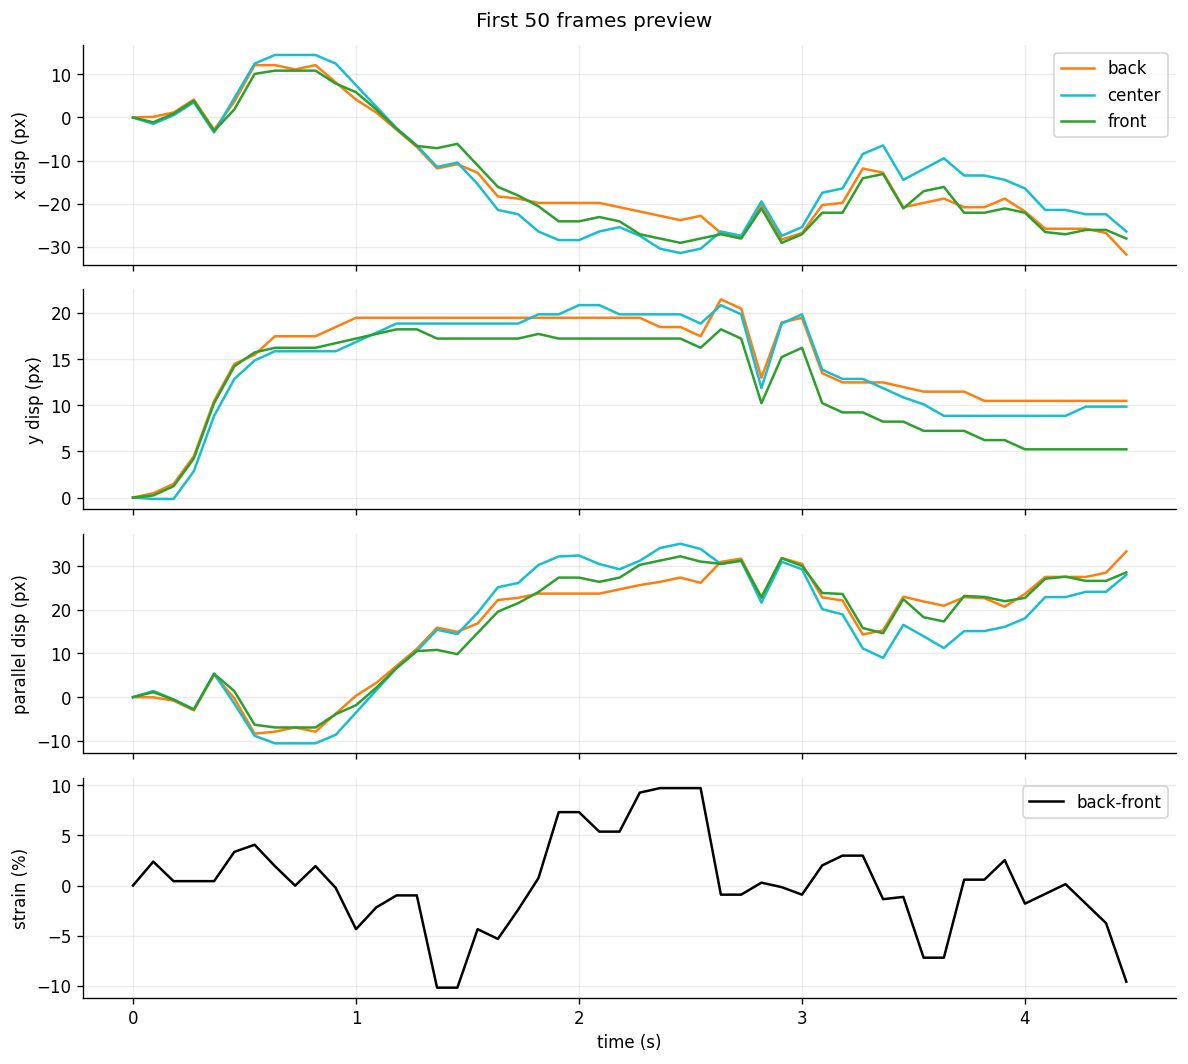

Saved preview plot: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_figures/preview_first50_displacement_strain.png


In [8]:
preview_strain = strain_series(preview_tracking["positions"], t_hat)

fig, axes = plt.subplots(4, 1, figsize=(10, 9), sharex=True)
for point_id in POINT_ORDER:
    sub = preview_df[preview_df["point_id"] == point_id]
    axes[0].plot(sub["time_s"], sub["cumulative_dx"], label=point_id, color=POINT_COLORS[point_id])
    axes[1].plot(sub["time_s"], sub["cumulative_dy"], label=point_id, color=POINT_COLORS[point_id])
    axes[2].plot(sub["time_s"], sub["d_parallel_px"], label=point_id, color=POINT_COLORS[point_id])
axes[3].plot(time_s[:preview_n], preview_strain["strain_back_front_percent"], color="black", label="back-front")

axes[0].set_ylabel("x disp (px)")
axes[1].set_ylabel("y disp (px)")
axes[2].set_ylabel("parallel disp (px)")
axes[3].set_ylabel("strain (%)")
axes[3].set_xlabel("time (s)")
axes[0].legend(loc="best")
axes[3].legend(loc="best")
fig.suptitle("First 50 frames preview")
fig.tight_layout()
preview_path = FIG_DIR / "preview_first50_displacement_strain.png"
fig.savefig(preview_path)
plt.show()
print(f"Saved preview plot: {preview_path}")


## Full-sequence run and CSV export


In [9]:
full_tracking = track_three_points(frames, initial_points, CFG, max_frames=len(frames))
tracking_df = tracking_dataframe(full_tracking, time_s, t_hat, n_hat, mm_per_pixel)
tracking_df.to_csv(CSV_PATH, index=False)

full_strain = strain_series(full_tracking["positions"], t_hat)
print(f"Saved tracking CSV: {CSV_PATH}")
print(f"Rows: {len(tracking_df)}")
display(tracking_df.head(9))
display(tracking_df.tail(9))


Saved tracking CSV: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_fascicle_speckle_tracking.csv
Rows: 252


,frame,time_s,point_id,x,y,dx,dy,cumulative_dx,cumulative_dy,d_parallel_px,...,fallback_used,strain_back_front_percent,strain_back_center_percent,strain_center_front_percent,dx_mm,dy_mm,cumulative_dx_mm,cumulative_dy_mm,d_parallel_mm,d_perpendicular_mm
0,0,0.000000,back,367.844001,223.525878,0.000000,0.000000,0.000000,0.000000,0.000000,...,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0,0.000000,center,343.484750,229.149654,0.000000,0.000000,0.000000,0.000000,0.000000,...,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0,0.000000,front,319.125498,234.773431,0.000000,0.000000,0.000000,0.000000,0.000000,...,False,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,0.090909,back,368.000000,224.000000,0.155999,0.474122,0.155999,0.474122,-0.045346,...,False,2.38593,5.833508,-1.061648,0.009886,0.030047,0.009886,0.030047,-0.002874,-0.031501
4,1,0.090909,center,342.000000,229.000000,-1.484750,-0.149654,-1.484750,-0.149654,1.413031,...,False,2.38593,5.833508,-1.061648,-0.094096,-0.009484,-0.094096,-0.009484,0.089551,0.030408
5,1,0.090909,front,318.000000,235.000000,-1.125498,0.226569,-1.125498,0.226569,1.147619,...,False,2.38593,5.833508,-1.061648,-0.071328,0.014359,-0.071328,0.014359,0.072730,0.002055
6,2,0.181818,back,369.000000,225.000000,1.000000,1.000000,1.155999,1.474122,-0.794765,...,False,0.43719,1.036223,-0.161844,0.063375,0.063375,0.073261,0.093422,-0.050368,-0.107508
7,2,0.181818,center,344.000000,229.000000,2.000000,0.000000,0.515250,-0.149654,-0.535709,...,False,0.43719,1.036223,-0.161844,0.126750,0.000000,0.032654,-0.009484,-0.033951,0.001896
8,2,0.181818,front,320.000000,236.000000,2.000000,1.000000,0.874502,1.226569,-0.576170,...,False,0.43719,1.036223,-0.161844,0.126750,0.063375,0.055422,0.077734,-0.036515,-0.088209


,frame,time_s,point_id,x,y,dx,dy,cumulative_dx,cumulative_dy,d_parallel_px,...,fallback_used,strain_back_front_percent,strain_back_center_percent,strain_center_front_percent,dx_mm,dy_mm,cumulative_dx_mm,cumulative_dy_mm,d_parallel_mm,d_perpendicular_mm
243,81,7.363636,back,403.00,238.0,0.00,0.0,35.155999,14.474122,-30.998984,...,False,26.819747,49.908872,3.730622,0.000000,0.000000,2.228011,0.917297,-1.964561,-1.394981
244,81,7.363636,center,368.00,253.0,0.00,0.0,24.515250,23.850346,-18.521766,...,False,26.819747,49.908872,3.730622,0.000000,0.000000,1.553654,1.511516,-1.173817,-1.822272
245,81,7.363636,front,340.00,247.0,0.00,0.0,20.874502,12.226569,-17.589110,...,True,26.819747,49.908872,3.730622,0.000000,0.000000,1.322922,0.774859,-1.114710,-1.052592
246,82,7.454545,back,404.00,237.0,1.00,-1.0,36.155999,13.474122,-32.198305,...,False,28.768487,51.857613,5.679362,0.063375,-0.063375,2.291386,0.853922,-2.040568,-1.347486
247,82,7.454545,center,368.50,252.0,0.50,-1.0,25.015250,22.850346,-19.233902,...,True,28.768487,51.857613,5.679362,0.031688,-0.063375,1.585341,1.448141,-1.218949,-1.767649
248,82,7.454545,front,340.00,246.0,0.00,-1.0,20.874502,11.226569,-17.814061,...,False,28.768487,51.857613,5.679362,0.000000,-0.063375,1.322922,0.711484,-1.128966,-0.990841
249,83,7.545455,back,403.00,236.0,-1.00,-1.0,35.155999,12.474122,-31.448886,...,False,28.506253,50.808677,6.203830,-0.063375,-0.063375,2.228011,0.790547,-1.993073,-1.271479
250,83,7.545455,center,368.00,252.0,-0.50,0.0,24.515250,22.850346,-18.746717,...,False,28.506253,50.808677,6.203830,-0.031688,0.000000,1.553654,1.448141,-1.188073,-1.760521
251,83,7.545455,front,339.25,245.5,-0.75,-0.5,20.124502,10.726569,-17.195759,...,True,28.506253,50.808677,6.203830,-0.047531,-0.031688,1.275390,0.679796,-1.089781,-0.949274


## Visual outputs

The required figures are saved under `results/june30_4_best/three_point_speckle_figures/`.


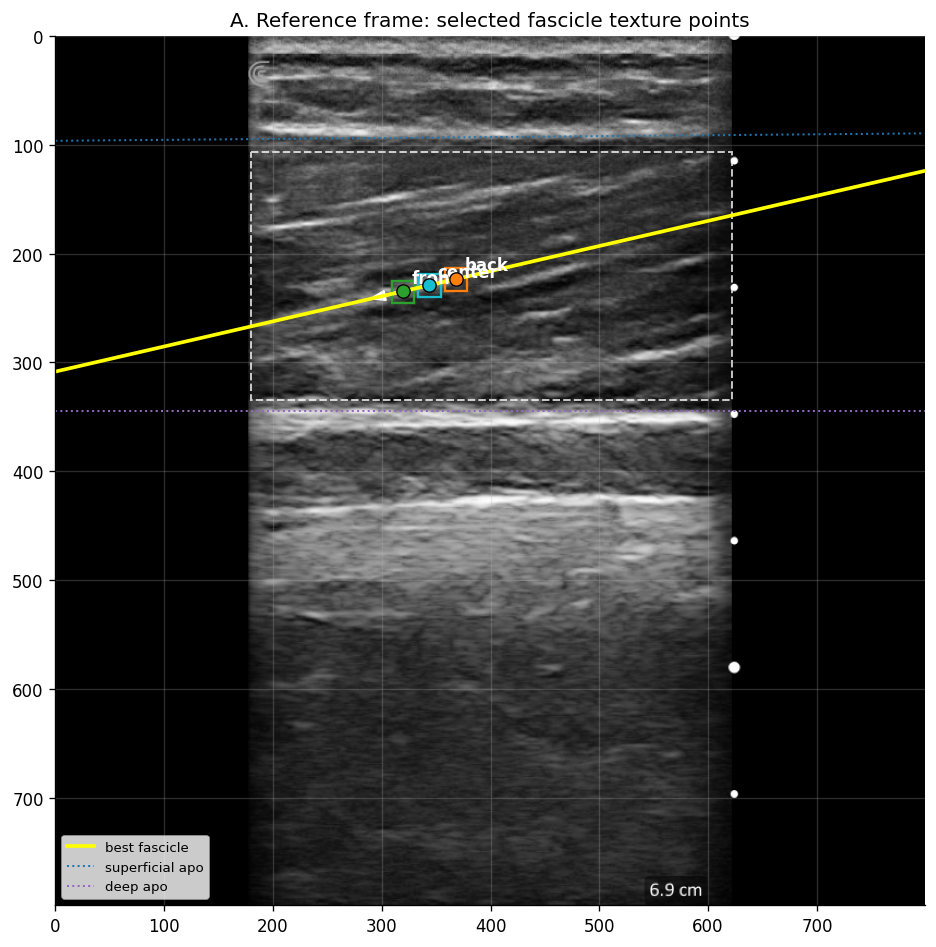

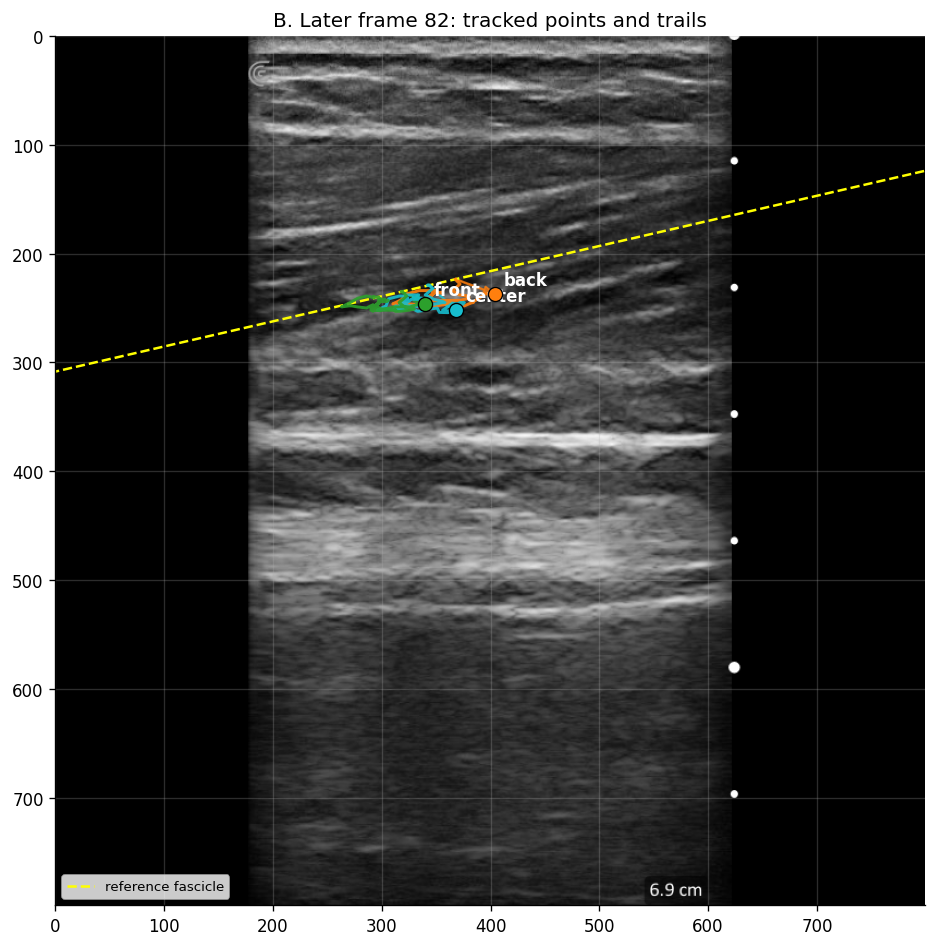

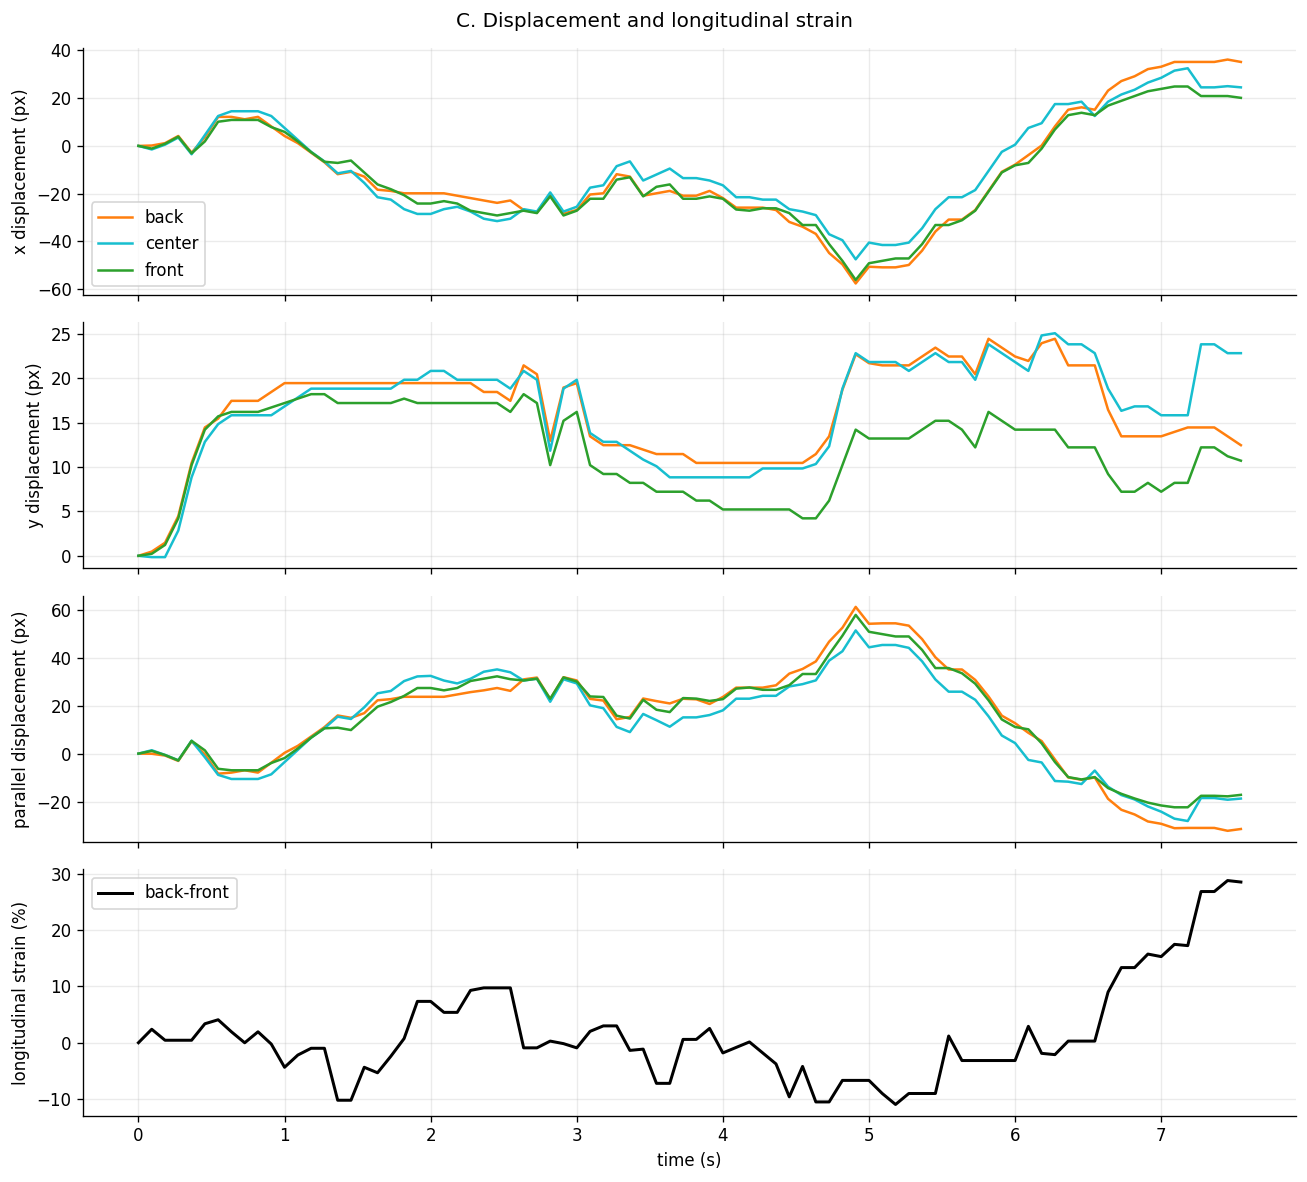

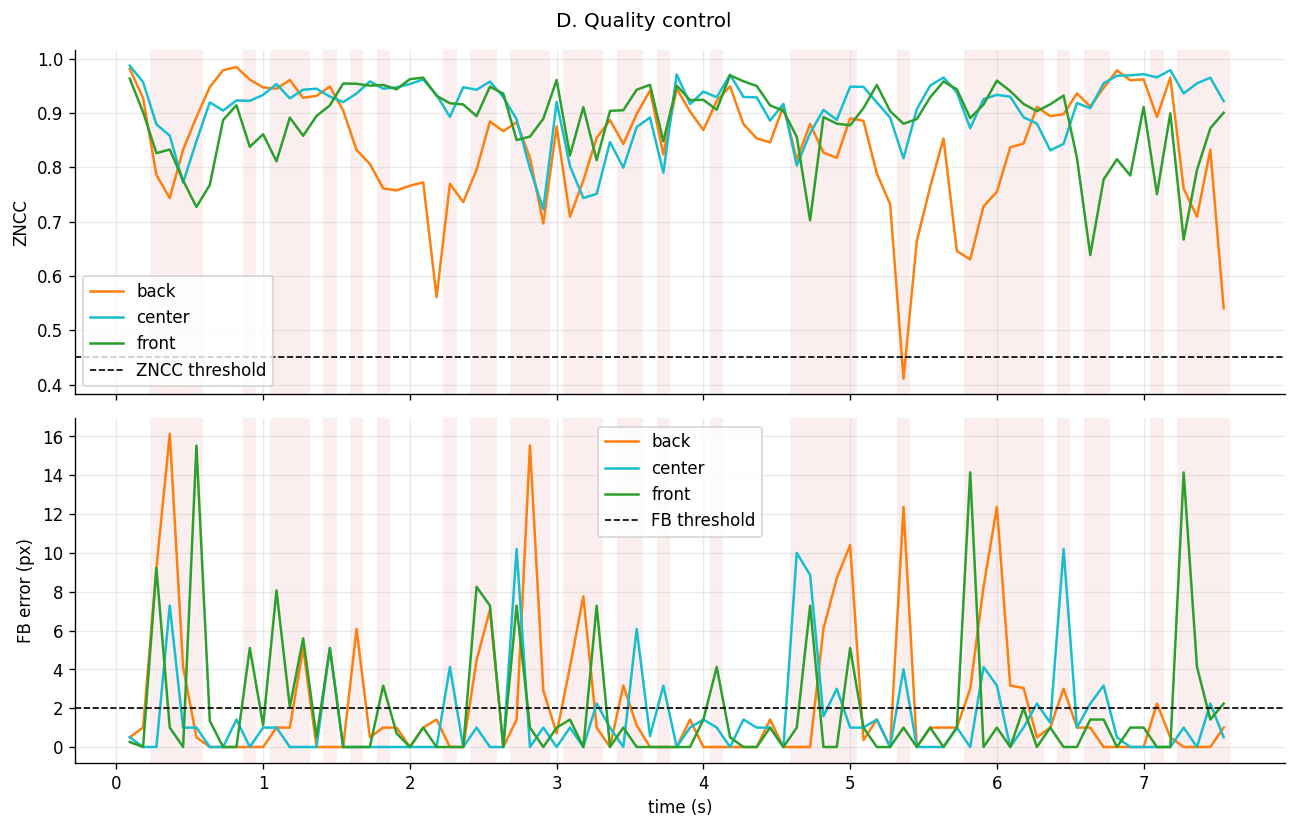

Saved figures:
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_figures/A_reference_frame_three_points.png
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_figures/B_later_frame_trails_displacement.png
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_figures/C_time_series_displacement_strain.png
/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_figures/D_quality_control_zncc_fb.png


In [10]:
def draw_roi_patch(ax, roi_tuple, color="white", linewidth=1.2, alpha=0.75):
    x, y, w, h = roi_tuple
    ax.add_patch(Rectangle((x, y), w, h, fill=False, edgecolor=color, linewidth=linewidth, alpha=alpha, linestyle="--"))


def draw_patch_box(ax, point, cfg, color):
    half = int(cfg.block_size) // 2
    ax.add_patch(
        Rectangle(
            (float(point[0]) - half, float(point[1]) - half),
            int(cfg.block_size),
            int(cfg.block_size),
            fill=False,
            edgecolor=color,
            linewidth=1.4,
        )
    )


def plot_line(ax, line, color, label=None, linewidth=2.0, linestyle="-"):
    if line is None:
        return
    ax.plot([line[0], line[2]], [line[1], line[3]], color=color, linewidth=linewidth, linestyle=linestyle, label=label)


fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(frames[0], cmap="gray", vmin=0, vmax=255)
draw_roi_patch(ax, fascicle_roi, color="white")
plot_line(ax, fascicle_line0, color="yellow", label="best fascicle", linewidth=2.2)
plot_line(ax, sup_apo0, color="tab:blue", label="superficial apo", linewidth=1.2, linestyle=":")
plot_line(ax, deep_apo0, color="tab:purple", label="deep apo", linewidth=1.2, linestyle=":")
center_point = initial_points["center"]
ax.arrow(center_point[0], center_point[1], 55 * t_hat[0], 55 * t_hat[1], color="white", width=1.5, head_width=9, length_includes_head=True)
for point_id in POINT_ORDER:
    point = initial_points[point_id]
    ax.scatter(point[0], point[1], s=64, color=POINT_COLORS[point_id], edgecolor="black", linewidth=0.8, zorder=5)
    draw_patch_box(ax, point, CFG, POINT_COLORS[point_id])
    ax.text(point[0] + 8, point[1] - 8, point_id, color="white", fontsize=10, weight="bold")
ax.set_title("A. Reference frame: selected fascicle texture points")
ax.set_xlim(0, frame_shape[1] - 1)
ax.set_ylim(frame_shape[0] - 1, 0)
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
fig_a_path = FIG_DIR / "A_reference_frame_three_points.png"
fig.savefig(fig_a_path)
plt.show()

strain_abs = np.abs(full_strain["strain_back_front_percent"].to_numpy(dtype=np.float64))
if np.any(np.isfinite(strain_abs)):
    representative_idx = int(np.nanargmax(strain_abs))
else:
    representative_idx = min(len(frames) - 1, max(1, len(frames) // 2))

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(frames[representative_idx], cmap="gray", vmin=0, vmax=255)
plot_line(ax, fascicle_line0, color="yellow", label="reference fascicle", linewidth=1.5, linestyle="--")
for point_idx, point_id in enumerate(POINT_ORDER):
    trail = full_tracking["positions"][: representative_idx + 1, point_idx, :]
    ax.plot(trail[:, 0], trail[:, 1], color=POINT_COLORS[point_id], linewidth=1.8, alpha=0.9)
    p_start = full_tracking["positions"][0, point_idx]
    p_now = full_tracking["positions"][representative_idx, point_idx]
    ax.scatter(p_now[0], p_now[1], s=72, color=POINT_COLORS[point_id], edgecolor="black", linewidth=0.8, zorder=5)
    ax.arrow(p_start[0], p_start[1], p_now[0] - p_start[0], p_now[1] - p_start[1], color=POINT_COLORS[point_id], width=0.8, head_width=7, length_includes_head=True, alpha=0.75)
    ax.text(p_now[0] + 8, p_now[1] - 8, point_id, color="white", fontsize=10, weight="bold")
ax.set_title(f"B. Later frame {representative_idx}: tracked points and trails")
ax.set_xlim(0, frame_shape[1] - 1)
ax.set_ylim(frame_shape[0] - 1, 0)
ax.legend(loc="lower left", fontsize=8)
fig.tight_layout()
fig_b_path = FIG_DIR / "B_later_frame_trails_displacement.png"
fig.savefig(fig_b_path)
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=True)
for point_id in POINT_ORDER:
    sub = tracking_df[tracking_df["point_id"] == point_id]
    axes[0].plot(sub["time_s"], sub["cumulative_dx"], label=point_id, color=POINT_COLORS[point_id])
    axes[1].plot(sub["time_s"], sub["cumulative_dy"], label=point_id, color=POINT_COLORS[point_id])
    axes[2].plot(sub["time_s"], sub["d_parallel_px"], label=point_id, color=POINT_COLORS[point_id])
axes[3].plot(time_s, full_strain["strain_back_front_percent"], color="black", linewidth=1.8, label="back-front")
axes[0].set_ylabel("x displacement (px)")
axes[1].set_ylabel("y displacement (px)")
axes[2].set_ylabel("parallel displacement (px)")
axes[3].set_ylabel("longitudinal strain (%)")
axes[3].set_xlabel("time (s)")
axes[0].legend(loc="best")
axes[3].legend(loc="best")
fig.suptitle("C. Displacement and longitudinal strain")
fig.tight_layout()
fig_c_path = FIG_DIR / "C_time_series_displacement_strain.png"
fig.savefig(fig_c_path)
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
invalid_frames = sorted(tracking_df.loc[(~tracking_df["valid"]) | (tracking_df["fallback_used"]), "frame"].unique().tolist())
for frame_idx in invalid_frames:
    t0 = time_s[int(frame_idx)] if np.isfinite(time_s[int(frame_idx)]) else float(frame_idx)
    width = 0.5 / fps if np.isfinite(fps) and fps > 0 else 0.5
    for ax in axes:
        ax.axvspan(t0 - width, t0 + width, color="tab:red", alpha=0.08, linewidth=0)
for point_id in POINT_ORDER:
    sub = tracking_df[tracking_df["point_id"] == point_id]
    axes[0].plot(sub["time_s"], sub["zncc"], label=point_id, color=POINT_COLORS[point_id])
    axes[1].plot(sub["time_s"], sub["forward_backward_error"], label=point_id, color=POINT_COLORS[point_id])
axes[0].axhline(ZNCC_THRESHOLD, color="black", linestyle="--", linewidth=1, label="ZNCC threshold")
axes[1].axhline(FB_ERROR_THRESHOLD_PX, color="black", linestyle="--", linewidth=1, label="FB threshold")
axes[0].set_ylabel("ZNCC")
axes[1].set_ylabel("FB error (px)")
axes[1].set_xlabel("time (s)")
axes[0].legend(loc="best")
axes[1].legend(loc="best")
fig.suptitle("D. Quality control")
fig.tight_layout()
fig_d_path = FIG_DIR / "D_quality_control_zncc_fb.png"
fig.savefig(fig_d_path)
plt.show()

print("Saved figures:")
for path in [fig_a_path, fig_b_path, fig_c_path, fig_d_path]:
    print(path)


## Optional annotated overlay video

This sequence has only 84 frames, so the overlay video is fast enough to write by default. Set `MAKE_ANNOTATED_VIDEO = False` if you only want static figures.


In [11]:
MAKE_ANNOTATED_VIDEO = True


def gray_to_bgr(frame: np.ndarray) -> np.ndarray:
    arr = np.asarray(frame)
    if arr.dtype != np.uint8:
        arr = np.clip(arr, 0, 255).astype(np.uint8)
    return cv2.cvtColor(arr, cv2.COLOR_GRAY2BGR) if arr.ndim == 2 else arr.copy()


def color_bgr(point_id: str) -> tuple[int, int, int]:
    return {
        "back": (0, 165, 255),
        "center": (255, 255, 0),
        "front": (0, 200, 0),
    }[point_id]


def write_overlay_video(path: Path, frames_in: list[np.ndarray], tracking: dict[str, np.ndarray], strain_df: pd.DataFrame):
    height, width = frames_in[0].shape[:2]
    video_fps = fps if np.isfinite(fps) and fps > 0 else 10.0
    writer = cv2.VideoWriter(str(path), cv2.VideoWriter_fourcc(*"mp4v"), video_fps, (width, height))
    if not writer.isOpened():
        raise RuntimeError(f"Could not open video writer for {path}")

    line_int = np.rint(fascicle_line0).astype(int)
    for frame_idx, frame in enumerate(frames_in):
        vis = gray_to_bgr(frame)
        cv2.line(vis, (line_int[0], line_int[1]), (line_int[2], line_int[3]), (0, 255, 255), 2, cv2.LINE_AA)
        for point_idx, point_id in enumerate(POINT_ORDER):
            pts = tracking["positions"][: frame_idx + 1, point_idx, :]
            bgr = color_bgr(point_id)
            for a, b in zip(pts[:-1], pts[1:]):
                if np.all(np.isfinite(a)) and np.all(np.isfinite(b)):
                    cv2.line(vis, tuple(np.rint(a).astype(int)), tuple(np.rint(b).astype(int)), bgr, 2, cv2.LINE_AA)
            p = tracking["positions"][frame_idx, point_idx]
            if np.all(np.isfinite(p)):
                cv2.circle(vis, tuple(np.rint(p).astype(int)), 6, bgr, -1, cv2.LINE_AA)
                cv2.circle(vis, tuple(np.rint(p).astype(int)), 7, (0, 0, 0), 1, cv2.LINE_AA)
        strain_value = float(strain_df.loc[frame_idx, "strain_back_front_percent"])
        cv2.putText(vis, f"frame {frame_idx:03d}  BF strain {strain_value:+.2f}%", (18, 34), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 0), 4, cv2.LINE_AA)
        cv2.putText(vis, f"frame {frame_idx:03d}  BF strain {strain_value:+.2f}%", (18, 34), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 1, cv2.LINE_AA)
        writer.write(vis)
    writer.release()


if MAKE_ANNOTATED_VIDEO:
    write_overlay_video(VIDEO_OVERLAY_PATH, frames, full_tracking, full_strain)
    print(f"Saved annotated video: {VIDEO_OVERLAY_PATH}")
else:
    print("Annotated video skipped.")


Saved annotated video: /Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_figures/three_point_speckle_overlay.mp4


## Summary statistics and conclusion


In [12]:
summary = {
    "mean_zncc": float(tracking_df["zncc"].mean(skipna=True)),
    "median_zncc": float(tracking_df["zncc"].median(skipna=True)),
    "invalid_rows": int((~tracking_df["valid"]).sum()),
    "fallback_rows": int(tracking_df["fallback_used"].sum()),
    "invalid_frames": int(tracking_df.loc[(~tracking_df["valid"]) | tracking_df["fallback_used"], "frame"].nunique()),
    "max_cumulative_displacement_px": float(
        np.nanmax(np.hypot(tracking_df["cumulative_dx"], tracking_df["cumulative_dy"]))
    ),
    "peak_abs_longitudinal_strain_percent": float(np.nanmax(np.abs(full_strain["strain_back_front_percent"]))),
    "peak_longitudinal_strain_percent": float(full_strain["strain_back_front_percent"].iloc[np.nanargmax(np.abs(full_strain["strain_back_front_percent"]))]),
}
if has_mm_calibration:
    summary["max_cumulative_displacement_mm"] = summary["max_cumulative_displacement_px"] * float(mm_per_pixel)

summary_path = OUT_DIR / "three_point_speckle_summary.json"
summary_path.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

bad_frame_list = sorted(tracking_df.loc[(~tracking_df["valid"]) | tracking_df["fallback_used"], "frame"].unique().astype(int).tolist())
bad_frame_text = ", ".join(str(v) for v in bad_frame_list[:18])
if len(bad_frame_list) > 18:
    bad_frame_text += ", ..."
if not bad_frame_text:
    bad_frame_text = "none"

fallback_fraction = summary["fallback_rows"] / max(len(tracking_df), 1)
looks_stable = summary["mean_zncc"] >= 0.70 and fallback_fraction <= 0.15
if looks_stable:
    stability_sentence = "The tracking looks broadly stable by the automated QC thresholds."
else:
    stability_sentence = "The tracking needs visual review because low-confidence or fallback rows are non-trivial."

if summary["peak_abs_longitudinal_strain_percent"] <= 15:
    plausibility_sentence = "The back-front strain magnitude is in a plausible exploratory range for this simplified pixel-space analysis."
else:
    plausibility_sentence = "The back-front strain magnitude is large enough that the trail overlays and QC figure should be inspected before interpreting it biologically."

display(
    Markdown(
        f'''
        ### Short conclusion

        - Stability: {stability_sentence}
        - Texture following: the three points remain constrained to local fascicle speckle patches in the overlay; fallback frames are explicitly flagged rather than accepted silently.
        - Longitudinal strain: {plausibility_sentence}
        - Failing or low-confidence frames: {bad_frame_text}.
        - Likely failure modes: low local texture, decorrelation from out-of-plane motion, or local patch ambiguity near similar speckle patterns.

        Outputs written:

        - CSV: `{CSV_PATH}`
        - Figures: `{FIG_DIR}`
        - Summary JSON: `{summary_path}`
        '''
    )
)


{
  "mean_zncc": 0.8781386118337332,
  "median_zncc": 0.9033136963844299,
  "invalid_rows": 60,
  "fallback_rows": 60,
  "invalid_frames": 44,
  "max_cumulative_displacement_px": 61.9148988880094,
  "peak_abs_longitudinal_strain_percent": 28.76848723097677,
  "peak_longitudinal_strain_percent": 28.76848723097677,
  "max_cumulative_displacement_mm": 3.9238567170275958
}



        ### Short conclusion

        - Stability: The tracking needs visual review because low-confidence or fallback rows are non-trivial.
        - Texture following: the three points remain constrained to local fascicle speckle patches in the overlay; fallback frames are explicitly flagged rather than accepted silently.
        - Longitudinal strain: The back-front strain magnitude is large enough that the trail overlays and QC figure should be inspected before interpreting it biologically.
        - Failing or low-confidence frames: 3, 4, 5, 6, 10, 12, 13, 14, 16, 18, 20, 25, 27, 28, 30, 31, 32, 34, ....
        - Likely failure modes: low local texture, decorrelation from out-of-plane motion, or local patch ambiguity near similar speckle patterns.

        Outputs written:

        - CSV: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_fascicle_speckle_tracking.csv`
        - Figures: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_figures`
        - Summary JSON: `/Users/grosbedou/PycharmProjects/NDORMS/results/june30_4_best/three_point_speckle_summary.json`
        